In [55]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets.cifar import CIFAR10
from torchvision.transforms import Compose, Normalize, RandomCrop, RandomHorizontalFlip


In [28]:
# 데이터 전처리기 생성
transforms = Compose(
    [
        T.ToPILImage(),
        RandomCrop((32, 32), padding=4),
        RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261)),
    ]
)

In [29]:
# CIFAR-10 데이터셋 불러오기
training_data = CIFAR10(root='./', train=True, download=True, transform=transforms)
# 테스트 데이터에 똑같은 전처리기를 써도 되나?
test_data = CIFAR10(root='./', train=False, download=True, transform=transforms)

c:\Users\user\Documents\dl-with-pytorch\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


TypeError: Invalid shape (3, 32, 32) for image data

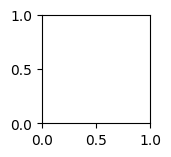

In [37]:
# 정규화된 이미지가 아닌 원본이미지로 나오는 이유가 뭐지...
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(transforms(training_data.data[i]))
plt.show()

In [ ]:
class BasicBlock(nn.Module):  # 기본 블록 정의
    # 기본 블록을 구성하는 층 정의
    def __init__(self, in_channels, out_channels, hidden_dim):
        # nn.Module 클래스의 요소 상속
        super().__init__()
        # 합성곱층 정의
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # stride는 커널의 이동 거리
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        return x

In [ ]:
# VGG 모델 정의 하기
class CNN(nn.Module):
    def __init__(self, num_classes):  # num_classes는 클래스 갯수
        super().__init__()

        # 합성곱 기본 블록 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # 분류기 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, outfeatures=num_classes)

        # 분류기의 활성화 함수
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, start_dim=1)  # 2차원 특징 맵을 1차원으로?

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [60]:
# 데이터 로더 정의
train_loader = DataLoader(training_data, batch_size=32, shuffle=True)
test_data = DataLoader(test_data, batch_size=32, shuffle=False)

In [63]:
# 학습을 진행할 프로세서 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# CNN모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

TypeError: Linear.__init__() got an unexpected keyword argument 'outfeatures'

In [ ]:
# 학습률 정의
lr = 1e-3

# 최적화 기법 정의
optim = Adam(model.parameters(), lr=lr)


for epoch in range(100):
    for data, label in train_loader:
        optim.zero_grad()

        preds = model(data.to(device))

        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    if epoch == 0 or epoch % 10 == 9:
        print(f'epoch{epoch + 1} loss:{loss.item()}')

# 모델 저장
torch.save(model.state_dict(), 'CIFAR.pth')

NameError: name 'model' is not defined